# Statistical analysis DESeq2

# Graphs bioinformatics

individuals

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import os
from matplotlib.lines import Line2D
from matplotlib import rcParams

# ── 1. STYLE CONFIGURATION ──────────────────────────────────────────────────
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
rcParams['font.size'] = 12

sns.set_style("whitegrid", {'axes.edgecolor': 'black', 'grid.color': '.90', 'grid.linestyle': '-'})

# ── 2. PATHWAYS AND SETTINGS ────────────────────────────────────────────────
STUDIES = {
    'PRJNA46333': "/home/marcos/PRJNA46333/PRJNA46333_2/table/master_table_mag_sialidase_gtdb_deseq2.tsv",
}

OUTPUT_PATH = "/home/marcos/Imagens/Resultados in silico/Individuais/Final_DESeq2_Metabolic_Plot_PRJNA46333.png"

METABOLIC_PALETTE = {
    'Sialidases': '#9b59b6',
    'Transporters': '#e67e22',
    'Catabolic Pathway': '#27ae60',
    'Inactive': '#eeeeee'
}
GENE_LIST = ['has_nanH', 'has_nanE', 'has_nanK', 'has_nanA', 'has_nanT']

# ── 3. DATA INTEGRATION ──────────────────────────────────────────────────────
df_list = []
for study_id, path in STUDIES.items():
    if os.path.exists(path):
        temp_df = pd.read_csv(path, sep='\t')
        temp_df['Study'] = study_id
        df_list.append(temp_df)
    else:
        print(f"File not found: {path}")

df = pd.concat(df_list, ignore_index=True)

for col in ['baseMean', 'log2FoldChange', 'padj']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['padj'] = df['padj'].fillna(1.0)
df['log2FoldChange'] = df['log2FoldChange'].fillna(0.0)
df['baseMean'] = df['baseMean'].fillna(0.0)

for gene in GENE_LIST:
    if gene in df.columns:
        df[gene] = df[gene].astype(str).str.upper().isin(['YES', 'TRUE', '1'])

# ── 4. AGGREGATION AND FILTERING ────────────────────────────────────────────
perfil_counts = df.groupby(['Species'] + GENE_LIST).size().reset_index(name='count')
perfil_majoritario = perfil_counts.sort_values('count', ascending=False).drop_duplicates('Species')

df_filtrado = pd.merge(df, perfil_majoritario[['Species'] + GENE_LIST], on=['Species'] + GENE_LIST)

bin_counts = df_filtrado.groupby(['Study', 'Species']).size().reset_index(name='bin_count')

df_agg = df_filtrado.groupby(['Study', 'Species']).agg({
    'baseMean': 'mean',
    'log2FoldChange': 'mean',
    'padj': 'min',
    **{g: 'any' for g in GENE_LIST if g in df_filtrado.columns}
}).reset_index()

df_agg = pd.merge(df_agg, bin_counts, on=['Study', 'Species'])

study_counts = df_agg.groupby('Species')['Study'].nunique()
multi_study_species = set(study_counts[study_counts >= 2].index)

top_30_species = df_agg.groupby('Species')['baseMean'].sum().nlargest(30).index.tolist()
df_plot = df_agg[df_agg['Species'].isin(top_30_species)].copy()

species_order = df_plot.groupby('Species')['log2FoldChange'].mean().sort_values().index.tolist()
sp_to_y = {sp: i for i, sp in enumerate(species_order)}
df_plot['Y_idx'] = df_plot['Species'].map(sp_to_y)

# ── 5. RELATIVE ABUNDANCE ───────────────────────────────────────────────────
study_totals = df_plot.groupby('Study')['baseMean'].transform('sum')
df_plot['Relative_Abundance'] = (df_plot['baseMean'] / study_totals) * 100

# ── 6. FIGURE CONFIGURATION ─────────────────────────────────────────────────
num_sp = len(species_order)
fig, ax = plt.subplots(1, 1, figsize=(8, max(10, num_sp * 0.45)))

meta_df = df_plot.groupby('Species').agg({g: 'any' for g in GENE_LIST}).reset_index()

# ── 7. PLOTTING LOOP ────────────────────────────────────────────────────────
for study in STUDIES.keys():
    sub_df = df_plot[df_plot['Study'] == study]
    
    sizes = (sub_df['Relative_Abundance'] / df_plot['Relative_Abundance'].max() * 1200) + 60
    
    ax.scatter(x=sub_df['log2FoldChange'], y=sub_df['Y_idx'], s=sizes, color='white', 
               edgecolors='black', linewidths=1.2, alpha=1.0, zorder=3)
    
    for _, row in sub_df.iterrows():
        ax.text(row['log2FoldChange'], row['Y_idx'], str(int(row['bin_count'])), 
                ha='center', va='center', fontsize=9, fontweight='bold', color='black', zorder=4)
        
        sig = "***" if row['padj'] < 0.001 else "**" if row['padj'] < 0.01 else "*" if row['padj'] < 0.05 else ""
        if sig:
            ax.text(row['log2FoldChange'], row['Y_idx'] + 0.35, sig, ha='center', va='center',
                    fontsize=12, fontweight='bold', color='black', zorder=4)
            
    ax.axvline(x=0, color='gray', linestyle='--', lw=1.5, zorder=1)
    ax.set_title(f"{study}", fontweight='bold', fontsize=14, pad=15)
    ax.set_xlabel("Log₂ Fold Change\n(HC ← | → AD)", fontsize=11, fontweight='bold', labelpad=10)
    ax.tick_params(axis='x', labelsize=11)
    
    xmin, xmax = ax.get_xlim()
    ax.set_xlim(xmin * 1.20, xmax * 1.20)
    ax.set_ylim(-1, num_sp)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── 8. Y-AXIS LABELS AND METABOLIC BARS ─────────────────────────────────────
ax.set_yticks(range(num_sp))
ax.set_yticklabels(species_order, fontstyle='italic', fontsize=11)
ax.tick_params(axis='y', pad=80) 

for label in ax.get_yticklabels():
    if label.get_text() in multi_study_species:
        label.set_fontweight('bold')

for i, sp in enumerate(species_order):
    if sp in meta_df['Species'].values:
        row = meta_df[meta_df['Species'] == sp].iloc[0]
        metabolic_info = [('has_nanH', 'Sialidases'), ('has_nanT', 'Transporters'), ('cat', 'Catabolic Pathway')]

        for j, (g_key, p_key) in enumerate(metabolic_info):
            if g_key == 'cat':
                present = all(row.get(g, False) for g in ['has_nanA', 'has_nanE', 'has_nanK'])
            else:
                present = row.get(g_key, False)

            color = METABOLIC_PALETTE[p_key] if present else METABOLIC_PALETTE['Inactive']
            ax.add_patch(plt.Rectangle((-0.18 + (j * 0.05), i - 0.30), 0.035, 0.60, clip_on=False,
                                            transform=ax.get_yaxis_transform(), facecolor=color, edgecolor='black', lw=0.5))

# ── 9. GLOBAL LEGEND ────────────────────────────────────────────────────────
size_samples = [df_plot['Relative_Abundance'].max() * 0.1, df_plot['Relative_Abundance'].max() * 0.5, df_plot['Relative_Abundance'].max()]
size_legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'{val:.2f}%',
           markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.2, alpha=1.0,
           markersize=np.sqrt(((val / df_plot['Relative_Abundance'].max()) * 1200) + 60))
    for val in size_samples if val > 0
]
if size_legend_elements:
    fig.legend(handles=size_legend_elements, title="Relative Abundance",
               loc='lower right', bbox_to_anchor=(0.90, 0.0351), ncol=1, frameon=True,
               title_fontproperties={'weight': 'bold'})

legend_els = [Line2D([0], [0], color=c, lw=10, label=l) for l, c in METABOLIC_PALETTE.items() if l != 'Inactive']
fig.legend(handles=legend_els, title="Metabolic Profile  ▌NanH  ▌NanT  ▌Catabolic",
           loc='lower left', bbox_to_anchor=(-0.2, 0.0351), ncol=1, frameon=True,
           title_fontproperties={'weight': 'bold'})

# ── 10. LAYOUT & SAVE ───────────────────────────────────────────────────────
plt.subplots_adjust(left=0.25, right=0.95, top=0.90, bottom=0.25)

plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
plt.show()

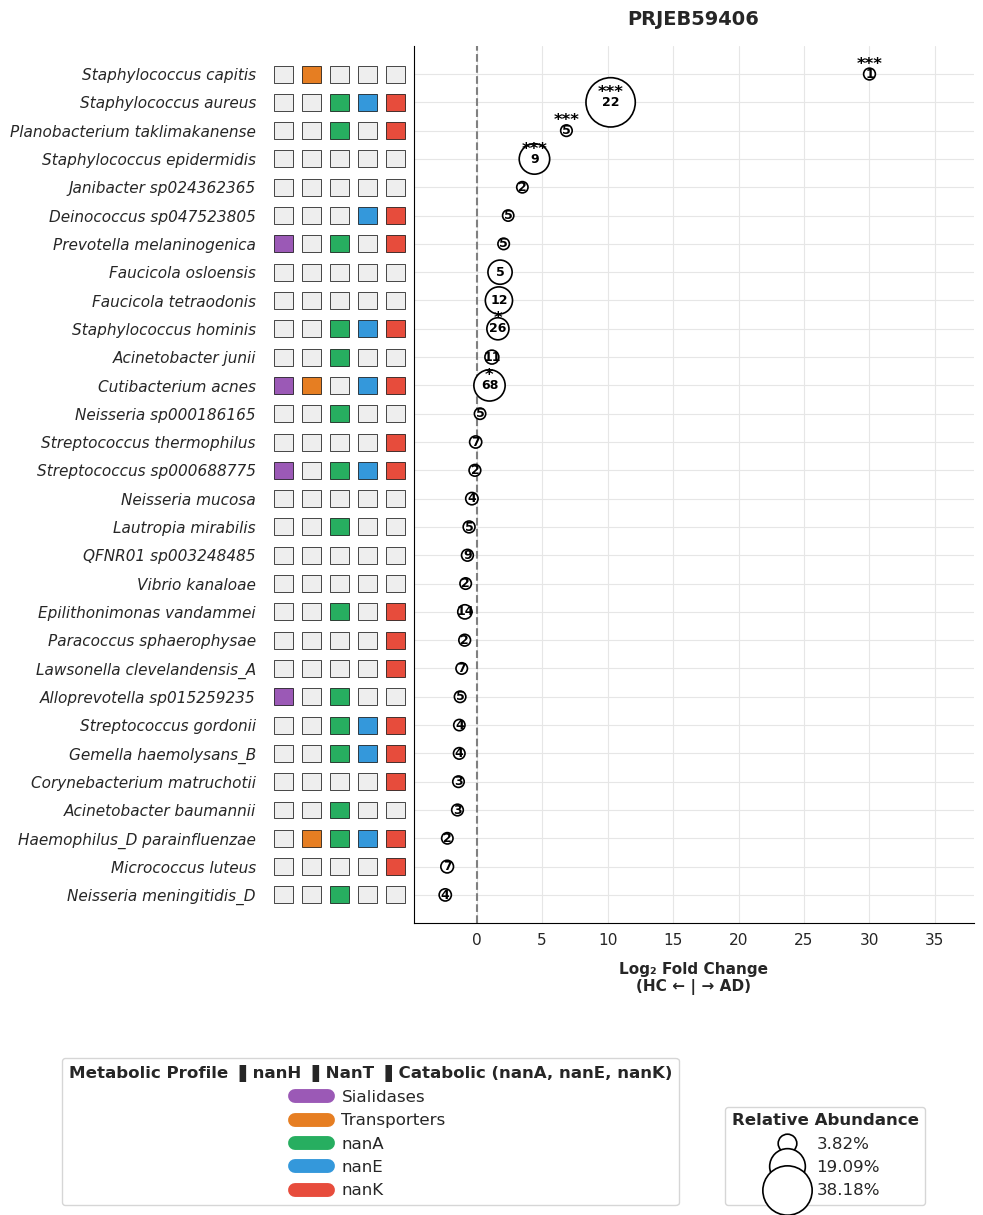

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import os
from matplotlib.lines import Line2D
from matplotlib import rcParams

# ── 1. STYLE CONFIGURATION ──────────────────────────────────────────────────
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
rcParams['font.size'] = 12

sns.set_style("whitegrid", {'axes.edgecolor': 'black', 'grid.color': '.90', 'grid.linestyle': '-'})

# ── 2. PATHWAYS AND SETTINGS ────────────────────────────────────────────────
STUDIES = {
    'PRJEB59406': "/home/marcos/PRJEB59406/table/master_table_mag_sialidase_gtdb_deseq2.tsv", 
}

OUTPUT_PATH = "/home/marcos/Imagens/Resultados in silico/Individuais/Final_DESeq2_Metabolic_Plot_PRJEB59406.png"

METABOLIC_PALETTE = {
    'Sialidases': '#9b59b6',
    'Transporters': '#e67e22',
    'nanA': '#27ae60',
    'nanE': '#3498db',
    'nanK': '#e74c3c',
    'Inactive': '#eeeeee'
}
GENE_LIST = ['has_nanH', 'has_nanE', 'has_nanK', 'has_nanA', 'has_nanT']

# ── 3. DATA INTEGRATION ──────────────────────────────────────────────────────
df_list = []
for study_id, path in STUDIES.items():
    if os.path.exists(path):
        temp_df = pd.read_csv(path, sep='\t')
        temp_df['Study'] = study_id
        df_list.append(temp_df)
    else:
        print(f"File not found: {path}")

df = pd.concat(df_list, ignore_index=True)

for col in ['baseMean', 'log2FoldChange', 'padj']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['padj'] = df['padj'].fillna(1.0)
df['log2FoldChange'] = df['log2FoldChange'].fillna(0.0)
df['baseMean'] = df['baseMean'].fillna(0.0)

for gene in GENE_LIST:
    if gene in df.columns:
        df[gene] = df[gene].astype(str).str.upper().isin(['YES', 'TRUE', '1'])

# ── 4. AGGREGATION AND FILTERING ────────────────────────────────────────────
perfil_counts = df.groupby(['Species'] + GENE_LIST).size().reset_index(name='count')
perfil_majoritario = perfil_counts.sort_values('count', ascending=False).drop_duplicates('Species')

df_filtrado = pd.merge(df, perfil_majoritario[['Species'] + GENE_LIST], on=['Species'] + GENE_LIST)

bin_counts = df_filtrado.groupby(['Study', 'Species']).size().reset_index(name='bin_count')

df_agg = df_filtrado.groupby(['Study', 'Species']).agg({
    'baseMean': 'mean',
    'log2FoldChange': 'mean',
    'padj': 'min',
    **{g: 'any' for g in GENE_LIST if g in df_filtrado.columns}
}).reset_index()

df_agg = pd.merge(df_agg, bin_counts, on=['Study', 'Species'])

study_counts = df_agg.groupby('Species')['Study'].nunique()
multi_study_species = set(study_counts[study_counts >= 2].index)

top_30_species = df_agg.groupby('Species')['baseMean'].sum().nlargest(30).index.tolist()
df_plot = df_agg[df_agg['Species'].isin(top_30_species)].copy()

species_order = df_plot.groupby('Species')['log2FoldChange'].mean().sort_values().index.tolist()
sp_to_y = {sp: i for i, sp in enumerate(species_order)}
df_plot['Y_idx'] = df_plot['Species'].map(sp_to_y)

# ── 5. RELATIVE ABUNDANCE ───────────────────────────────────────────────────
study_totals = df_plot.groupby('Study')['baseMean'].transform('sum')
df_plot['Relative_Abundance'] = (df_plot['baseMean'] / study_totals) * 100

# ── 6. FIGURE CONFIGURATION ─────────────────────────────────────────────────
num_sp = len(species_order)
fig, ax = plt.subplots(1, 1, figsize=(8, max(10, num_sp * 0.45)))

meta_df = df_plot.groupby('Species').agg({g: 'any' for g in GENE_LIST}).reset_index()

# ── 7. PLOTTING LOOP ────────────────────────────────────────────────────────
for study in STUDIES.keys():
    sub_df = df_plot[df_plot['Study'] == study]
    
    sizes = (sub_df['Relative_Abundance'] / df_plot['Relative_Abundance'].max() * 1200) + 60
    
    ax.scatter(x=sub_df['log2FoldChange'], y=sub_df['Y_idx'], s=sizes, color='white', 
               edgecolors='black', linewidths=1.2, alpha=1.0, zorder=3)
    
    for _, row in sub_df.iterrows():
        ax.text(row['log2FoldChange'], row['Y_idx'], str(int(row['bin_count'])), 
                ha='center', va='center', fontsize=9, fontweight='bold', color='black', zorder=4)
        
        sig = "***" if row['padj'] < 0.001 else "**" if row['padj'] < 0.01 else "*" if row['padj'] < 0.05 else ""
        if sig:
            ax.text(row['log2FoldChange'], row['Y_idx'] + 0.35, sig, ha='center', va='center',
                    fontsize=12, fontweight='bold', color='black', zorder=4)
            
    ax.axvline(x=0, color='gray', linestyle='--', lw=1.5, zorder=1)
    ax.set_title(f"{study}", fontweight='bold', fontsize=14, pad=15)
    ax.set_xlabel("Log₂ Fold Change\n(HC ← | → AD)", fontsize=11, fontweight='bold', labelpad=10)
    ax.tick_params(axis='x', labelsize=11)
    
    xmin, xmax = ax.get_xlim()
    ax.set_xlim(xmin * 1.20, xmax * 1.20)
    ax.set_ylim(-1, num_sp)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── 8. Y-AXIS LABELS AND METABOLIC BARS ─────────────────────────────────────
ax.set_yticks(range(num_sp))
ax.set_yticklabels(species_order, fontstyle='italic', fontsize=11)
ax.tick_params(axis='y', pad=110) 

for label in ax.get_yticklabels():
    if label.get_text() in multi_study_species:
        label.set_fontweight('bold')

for i, sp in enumerate(species_order):
    if sp in meta_df['Species'].values:
        row = meta_df[meta_df['Species'] == sp].iloc[0]
        metabolic_info = [('has_nanH', 'Sialidases'), ('has_nanT', 'Transporters'), ('has_nanA', 'nanA'), ('has_nanE', 'nanE'), ('has_nanK', 'nanK')]

        for j, (g_key, p_key) in enumerate(metabolic_info):
            if g_key == 'cat':
                present = all(row.get(g, False) for g in ['has_nanA', 'has_nanE', 'has_nanK'])
            else:
                present = row.get(g_key, False)
            color = METABOLIC_PALETTE[p_key] if present else METABOLIC_PALETTE['Inactive']
            ax.add_patch(plt.Rectangle((-0.25 + (j * 0.05), i - 0.30), 0.035, 0.60, clip_on=False,
                                            transform=ax.get_yaxis_transform(), facecolor=color, edgecolor='black', lw=0.5))

# ── 9. GLOBAL LEGEND ────────────────────────────────────────────────────────
size_samples = [df_plot['Relative_Abundance'].max() * 0.1, df_plot['Relative_Abundance'].max() * 0.5, df_plot['Relative_Abundance'].max()]
size_legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'{val:.2f}%',
           markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.2, alpha=1.0,
           markersize=np.sqrt(((val / df_plot['Relative_Abundance'].max()) * 1200) + 60))
    for val in size_samples if val > 0
]
if size_legend_elements:
    fig.legend(handles=size_legend_elements, title="Relative Abundance",
               loc='lower right', bbox_to_anchor=(0.90, 0.0351), ncol=1, frameon=True,
               title_fontproperties={'weight': 'bold'})

legend_els = [Line2D([0], [0], color=c, lw=10, label=l) for l, c in METABOLIC_PALETTE.items() if l != 'Inactive']
fig.legend(handles=legend_els, title="Metabolic Profile  ▌nanH  ▌NanT  ▌Catabolic (nanA, nanE, nanK)",
           loc='lower left', bbox_to_anchor=(-0.2, 0.0351), ncol=1, frameon=True,
           title_fontproperties={'weight': 'bold'})

# ── 10. LAYOUT & SAVE ───────────────────────────────────────────────────────
plt.subplots_adjust(left=0.25, right=0.95, top=0.90, bottom=0.25)

plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
plt.show()

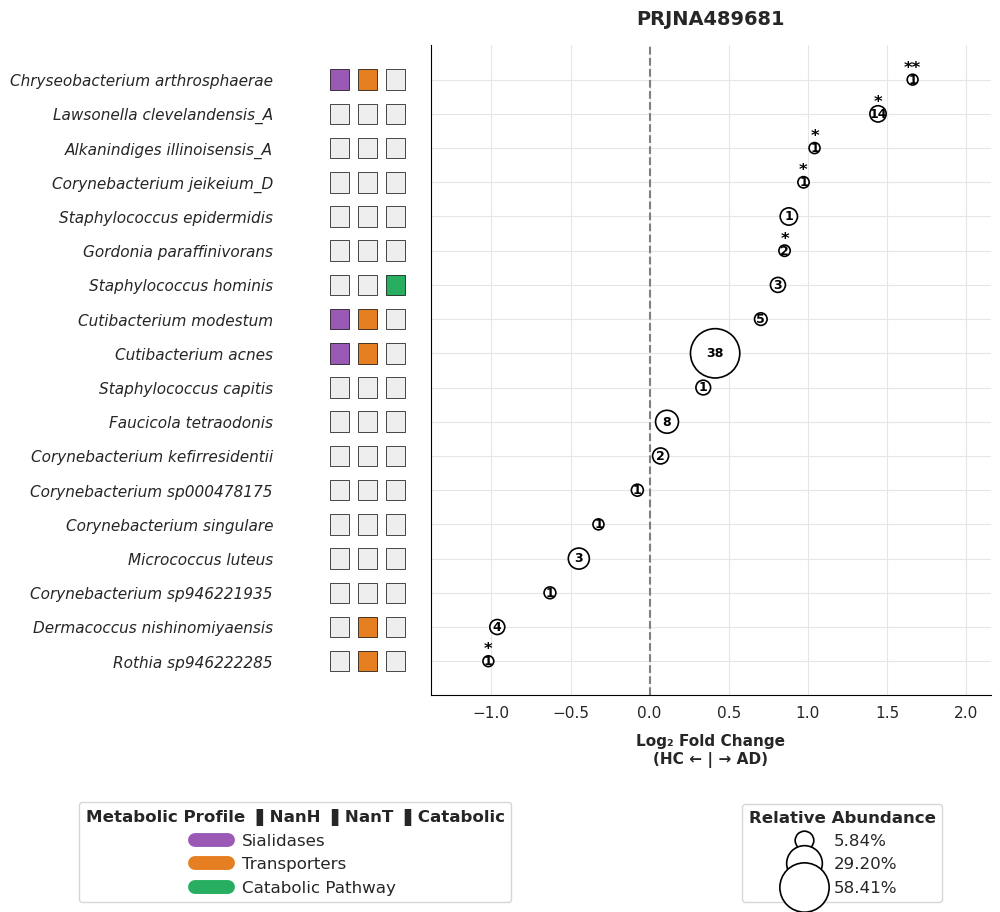

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import os
from matplotlib.lines import Line2D
from matplotlib import rcParams

# ── 1. STYLE CONFIGURATION ──────────────────────────────────────────────────
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
rcParams['font.size'] = 12

sns.set_style("whitegrid", {'axes.edgecolor': 'black', 'grid.color': '.90', 'grid.linestyle': '-'})

# ── 2. PATHWAYS AND SETTINGS ────────────────────────────────────────────────
STUDIES = {
    'PRJNA489681': "/home/marcos/PRJNA489681/table/master_table_mag_sialidase_gtdb_deseq2.tsv"
}

OUTPUT_PATH = "/home/marcos/Imagens/Resultados in silico/Individuais/Final_DESeq2_Metabolic_Plot_PRJNA489681.png"

METABOLIC_PALETTE = {
    'Sialidases': '#9b59b6',
    'Transporters': '#e67e22',
    'Catabolic Pathway': '#27ae60',
    'Inactive': '#eeeeee'
}
GENE_LIST = ['has_nanH', 'has_nanE', 'has_nanK', 'has_nanA', 'has_nanT']

# ── 3. DATA INTEGRATION ──────────────────────────────────────────────────────
df_list = []
for study_id, path in STUDIES.items():
    if os.path.exists(path):
        temp_df = pd.read_csv(path, sep='\t')
        temp_df['Study'] = study_id
        df_list.append(temp_df)
    else:
        print(f"File not found: {path}")

df = pd.concat(df_list, ignore_index=True)

for col in ['baseMean', 'log2FoldChange', 'padj']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['padj'] = df['padj'].fillna(1.0)
df['log2FoldChange'] = df['log2FoldChange'].fillna(0.0)
df['baseMean'] = df['baseMean'].fillna(0.0)

for gene in GENE_LIST:
    if gene in df.columns:
        df[gene] = df[gene].astype(str).str.upper().isin(['YES', 'TRUE', '1'])

# ── 4. AGGREGATION AND FILTERING ────────────────────────────────────────────
perfil_counts = df.groupby(['Species'] + GENE_LIST).size().reset_index(name='count')
perfil_majoritario = perfil_counts.sort_values('count', ascending=False).drop_duplicates('Species')

df_filtrado = pd.merge(df, perfil_majoritario[['Species'] + GENE_LIST], on=['Species'] + GENE_LIST)

bin_counts = df_filtrado.groupby(['Study', 'Species']).size().reset_index(name='bin_count')

df_agg = df_filtrado.groupby(['Study', 'Species']).agg({
    'baseMean': 'mean',
    'log2FoldChange': 'mean',
    'padj': 'min',
    **{g: 'any' for g in GENE_LIST if g in df_filtrado.columns}
}).reset_index()

df_agg = pd.merge(df_agg, bin_counts, on=['Study', 'Species'])

study_counts = df_agg.groupby('Species')['Study'].nunique()
multi_study_species = set(study_counts[study_counts >= 2].index)

top_30_species = df_agg.groupby('Species')['baseMean'].sum().nlargest(30).index.tolist()
df_plot = df_agg[df_agg['Species'].isin(top_30_species)].copy()

species_order = df_plot.groupby('Species')['log2FoldChange'].mean().sort_values().index.tolist()
sp_to_y = {sp: i for i, sp in enumerate(species_order)}
df_plot['Y_idx'] = df_plot['Species'].map(sp_to_y)

# ── 5. RELATIVE ABUNDANCE ───────────────────────────────────────────────────
study_totals = df_plot.groupby('Study')['baseMean'].transform('sum')
df_plot['Relative_Abundance'] = (df_plot['baseMean'] / study_totals) * 100

# ── 6. FIGURE CONFIGURATION ─────────────────────────────────────────────────
num_sp = len(species_order)
fig, ax = plt.subplots(1, 1, figsize=(8, max(10, num_sp * 0.45)))

meta_df = df_plot.groupby('Species').agg({g: 'any' for g in GENE_LIST}).reset_index()

# ── 7. PLOTTING LOOP ────────────────────────────────────────────────────────
for study in STUDIES.keys():
    sub_df = df_plot[df_plot['Study'] == study]
    
    sizes = (sub_df['Relative_Abundance'] / df_plot['Relative_Abundance'].max() * 1200) + 60
    
    ax.scatter(x=sub_df['log2FoldChange'], y=sub_df['Y_idx'], s=sizes, color='white', 
               edgecolors='black', linewidths=1.2, alpha=1.0, zorder=3)
    
    for _, row in sub_df.iterrows():
        ax.text(row['log2FoldChange'], row['Y_idx'], str(int(row['bin_count'])), 
                ha='center', va='center', fontsize=9, fontweight='bold', color='black', zorder=4)
        
        sig = "***" if row['padj'] < 0.001 else "**" if row['padj'] < 0.01 else "*" if row['padj'] < 0.05 else ""
        if sig:
            ax.text(row['log2FoldChange'], row['Y_idx'] + 0.35, sig, ha='center', va='center',
                    fontsize=12, fontweight='bold', color='black', zorder=4)
            
    ax.axvline(x=0, color='gray', linestyle='--', lw=1.5, zorder=1)
    ax.set_title(f"{study}", fontweight='bold', fontsize=14, pad=15)
    ax.set_xlabel("Log₂ Fold Change\n(HC ← | → AD)", fontsize=11, fontweight='bold', labelpad=10)
    ax.tick_params(axis='x', labelsize=11)
    
    xmin, xmax = ax.get_xlim()
    ax.set_xlim(xmin * 1.20, xmax * 1.20)
    ax.set_ylim(-1, num_sp)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── 8. Y-AXIS LABELS AND METABOLIC BARS ─────────────────────────────────────
ax.set_yticks(range(num_sp))
ax.set_yticklabels(species_order, fontstyle='italic', fontsize=11)
ax.tick_params(axis='y', pad=110) 

for label in ax.get_yticklabels():
    if label.get_text() in multi_study_species:
        label.set_fontweight('bold')

for i, sp in enumerate(species_order):
    if sp in meta_df['Species'].values:
        row = meta_df[meta_df['Species'] == sp].iloc[0]
        metabolic_info = [('has_nanH', 'Sialidases'), ('has_nanT', 'Transporters'), ('cat', 'Catabolic Pathway')]

        for j, (g_key, p_key) in enumerate(metabolic_info):
            if g_key == 'cat':
                present = all(row.get(g, False) for g in ['has_nanA', 'has_nanE', 'has_nanK'])
            else:
                present = row.get(g_key, False)

            color = METABOLIC_PALETTE[p_key] if present else METABOLIC_PALETTE['Inactive']
            ax.add_patch(plt.Rectangle((-0.18 + (j * 0.05), i - 0.30), 0.035, 0.60, clip_on=False,
                                            transform=ax.get_yaxis_transform(), facecolor=color, edgecolor='black', lw=0.5))

# ── 9. GLOBAL LEGEND ────────────────────────────────────────────────────────
size_samples = [df_plot['Relative_Abundance'].max() * 0.1, df_plot['Relative_Abundance'].max() * 0.5, df_plot['Relative_Abundance'].max()]
size_legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'{val:.2f}%',
           markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.2, alpha=1.0,
           markersize=np.sqrt(((val / df_plot['Relative_Abundance'].max()) * 1200) + 60))
    for val in size_samples if val > 0
]
if size_legend_elements:
    fig.legend(handles=size_legend_elements, title="Relative Abundance",
               loc='lower right', bbox_to_anchor=(0.90, 0.0351), ncol=1, frameon=True,
               title_fontproperties={'weight': 'bold'})

legend_els = [Line2D([0], [0], color=c, lw=10, label=l) for l, c in METABOLIC_PALETTE.items() if l != 'Inactive']
fig.legend(handles=legend_els, title="Metabolic Profile  ▌NanH  ▌NanT  ▌Catabolic",
           loc='lower left', bbox_to_anchor=(-0.2, 0.0351), ncol=1, frameon=True,
           title_fontproperties={'weight': 'bold'})

# ── 10. LAYOUT & SAVE ───────────────────────────────────────────────────────
plt.subplots_adjust(left=0.25, right=0.95, top=0.90, bottom=0.25)

plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
plt.show()

Heatmap

Presence of Top 20 Recovered Bacterial MAGs per Sample (Bold names indicate nanH+ species)

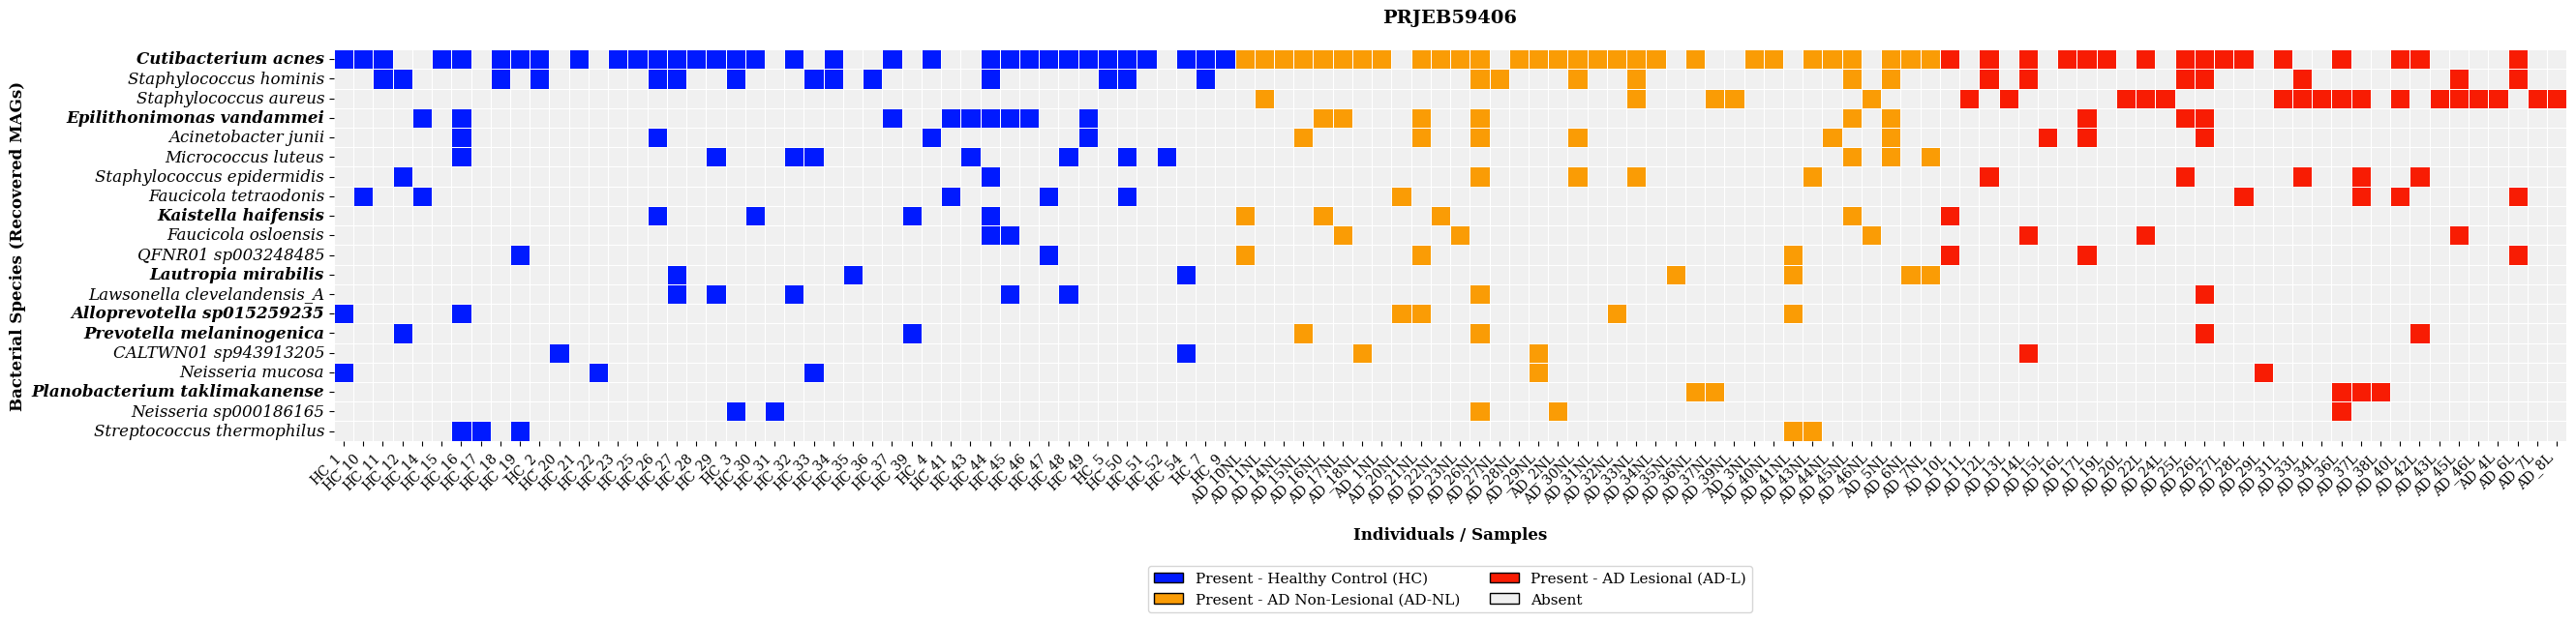


BACTERIAL SPECIES PREVALENCE TABLE (By Group)
            Bacterial Species  HC  AD-NL  AD-L  Total
          Cutibacterium acnes  33     29    16     78
       Staphylococcus hominis  14      6     7     27
        Staphylococcus aureus   0      5    17     22
    Epilithonimonas vandammei   9      6     3     18
          Acinetobacter junii   4      6     3     13
           Micrococcus luteus   8      3     0     11
   Staphylococcus epidermidis   2      4     5     11
        Faucicola tetraodonis   5      1     4     10
          Kaistella haifensis   4      4     1      9
          Faucicola osloensis   2      3     3      8
           QFNR01 sp003248485   2      3     3      8
          Lautropia mirabilis   3      4     0      7
  Lawsonella clevelandensis_A   5      1     1      7
   Alloprevotella sp015259235   2      4     0      6
    Prevotella melaninogenica   2      2     2      6
         CALTWN01 sp943913205   2      2     1      5
             Neisseria mucosa   3  

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib import rcParams

# Font and style setup
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
rcParams['font.size'] = 12

# File paths
DATA_PATH = "/home/marcos/PRJEB59406/table/master_table_mag_sialidase_gtdb_deseq2.tsv"
OUTPUT_PATH = "/home/marcos/Imagens/Resultados in silico/Individuais/Binary_Heatmap_PRJEB59406.png"

GENE_LIST = ['has_nanH', 'has_nanE', 'has_nanK', 'has_nanA', 'has_nanT']

# 1. Load data
df = pd.read_csv(DATA_PATH, sep='\t')

for gene in GENE_LIST:
    if gene in df.columns:
        df[gene] = df[gene].astype(str).str.upper().isin(['YES', 'TRUE', '1'])

perfil_counts = df.groupby(['Species'] + GENE_LIST).size().reset_index(name='count')
perfil_majoritario = perfil_counts.sort_values('count', ascending=False).drop_duplicates('Species')

df = pd.merge(df, perfil_majoritario[['Species'] + GENE_LIST], on=['Species'] + GENE_LIST)

# 2. Filter top 20 species 
top_20_species = df['Species'].value_counts().nlargest(20).index
df = df[df['Species'].isin(top_20_species)].copy()

# 3. Identify nanH positive species
if 'has_nanH' in df.columns:
    nanH_positive_species = set(
        df[df['has_nanH'] == True]['Species'].unique()
    )
else:
    nanH_positive_species = set()

# Sample ID extraction
def extract_sample_id(mag_id):
    mag_id_str = str(mag_id)
    if '_MAG_' in mag_id_str:
        # Remove também underlines extras no final do nome da amostra
        return mag_id_str.split('_MAG_')[0].rstrip('_') 
    return 'Co-assembly' if 'MAGScoT' in mag_id_str else mag_id_str

df['Sample'] = df['mag_id'].apply(extract_sample_id)

# 4. Create and sort matrix
binary_matrix = pd.crosstab(df['Species'], df['Sample']).clip(upper=1)

# Function to determine group order for sorting 
def get_group_order(sample_name):
    name_upper = sample_name.upper()
    if 'HC' in name_upper: return 0
    if 'NL' in name_upper: return 1
    return 2 # AD-L

sorted_cols = sorted(binary_matrix.columns, key=lambda x: (get_group_order(x), x))
binary_matrix = binary_matrix[sorted_cols]

# Ordened by prevalence (number of samples where species is present)
binary_matrix = binary_matrix.loc[binary_matrix.sum(axis=1).sort_values(ascending=False).index]

# 5. Differentiate HC (1), AD-NL (2), and AD-L (3) states
for col in binary_matrix.columns:
    if 'HC' in col.upper():
        pass # Mantém como 1
    elif 'NL' in col.upper():
        binary_matrix[col] = binary_matrix[col].replace(1, 2)
    else:
        binary_matrix[col] = binary_matrix[col].replace(1, 3)

# 6. Plotting setup
plt.figure(figsize=(max(12, len(binary_matrix.columns) * 0.9), max(7, len(binary_matrix.index) * 0.35)))

binary_cmap = mcolors.ListedColormap(['#f0f0f0', '#001aff', '#fa9c05', '#f81c03'])

ax = sns.heatmap(binary_matrix, cmap=binary_cmap, linewidths=0.5, linecolor='white', 
                 cbar=False, square=True, vmin=0, vmax=3)

# Labels and titles
plt.title("PRJEB59406", fontweight='bold', fontsize=14, pad=20)
plt.ylabel("Bacterial Species (Recovered MAGs)", fontweight='bold', fontsize=12)
plt.xlabel("Individuals / Samples", fontweight='bold', fontsize=12, labelpad=15)

# Format Y-axis labels (dynamic bold)
for label in ax.get_yticklabels():
    species_name = label.get_text()
    if species_name in nanH_positive_species:
        label.set_fontweight('bold')
    else:
        label.set_fontweight('normal')
    label.set_fontstyle('italic')

plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=10)

# Legend setup 
legend_elements = [
    Patch(facecolor="#001aff", edgecolor='black', label='Present - Healthy Control (HC)'),
    Patch(facecolor="#fa9c05", edgecolor='black', label='Present - AD Non-Lesional (AD-NL)'),
    Patch(facecolor="#f81c03", edgecolor='black', label='Present - AD Lesional (AD-L)'),
    Patch(facecolor='#f0f0f0', edgecolor='black', label='Absent')
]

ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=2, frameon=True, fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
plt.show()

hc_counts = (binary_matrix == 1).sum(axis=1)
nl_counts = (binary_matrix == 2).sum(axis=1)
l_counts = (binary_matrix == 3).sum(axis=1)
total_counts = (binary_matrix > 0).sum(axis=1)

prevalence_df = pd.DataFrame({
    'Bacterial Species': binary_matrix.index,
    'HC': hc_counts.values,
    'AD-NL': nl_counts.values,
    'AD-L': l_counts.values,
    'Total': total_counts.values
})

print("\n" + "="*80)
print("BACTERIAL SPECIES PREVALENCE TABLE (By Group)")
print("="*80)
print(prevalence_df.to_string(index=False))
print("="*80 + "\n")

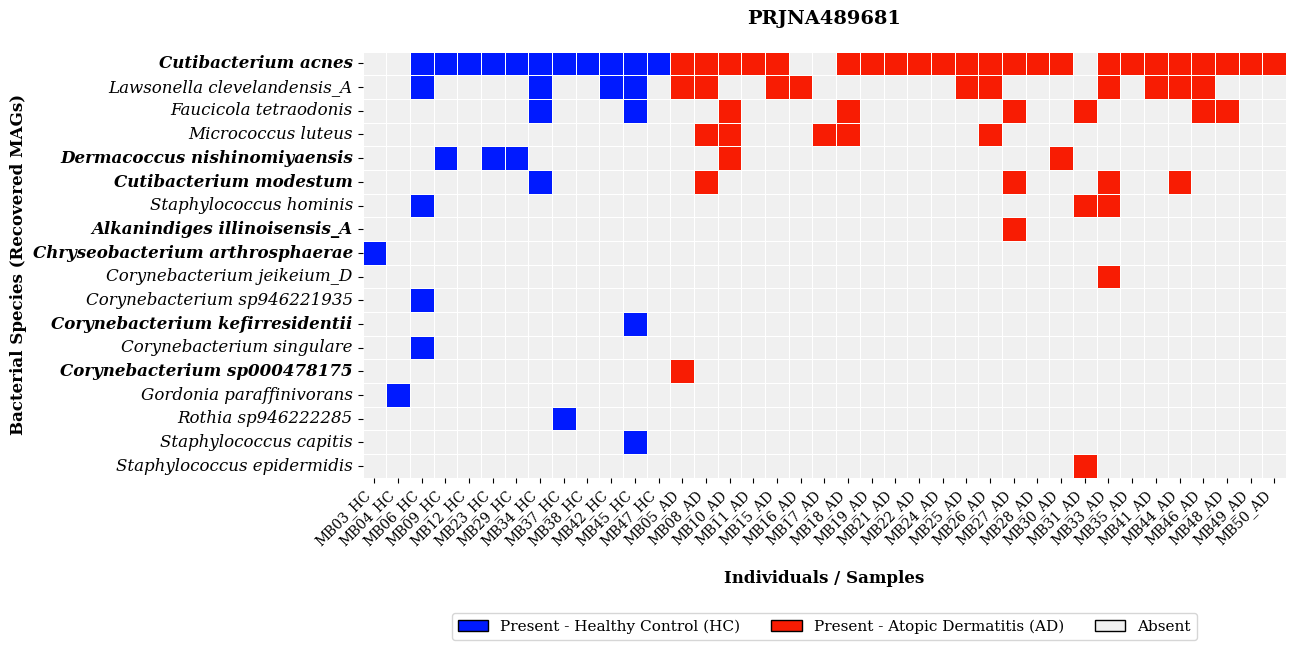


BACTERIAL SPECIES PREVALENCE TABLE (By Group)
              Bacterial Species  HC  AD  Total
            Cutibacterium acnes  11  23     34
    Lawsonella clevelandensis_A   4  10     14
          Faucicola tetraodonis   2   6      8
             Micrococcus luteus   0   5      5
   Dermacoccus nishinomiyaensis   3   2      5
         Cutibacterium modestum   1   4      5
         Staphylococcus hominis   1   2      3
   Alkanindiges illinoisensis_A   0   1      1
Chryseobacterium arthrosphaerae   1   0      1
     Corynebacterium jeikeium_D   0   1      1
    Corynebacterium sp946221935   1   0      1
Corynebacterium kefirresidentii   1   0      1
      Corynebacterium singulare   1   0      1
    Corynebacterium sp000478175   0   1      1
       Gordonia paraffinivorans   1   0      1
             Rothia sp946222285   1   0      1
         Staphylococcus capitis   1   0      1
     Staphylococcus epidermidis   0   1      1



In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib import rcParams

# Font and style setup
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
rcParams['font.size'] = 12

# File paths
DATA_PATH = "/home/marcos/PRJNA489681/table/master_table_mag_sialidase_gtdb_deseq2.tsv"
OUTPUT_PATH = "/home/marcos/Imagens/Resultados in silico/Individuais/Binary_Heatmap_PRJNA489681.png"

# List of genes to define the metabolic profile
GENE_LIST = ['has_nanH', 'has_nanE', 'has_nanK', 'has_nanA', 'has_nanT']

# 1. Load data
df = pd.read_csv(DATA_PATH, sep='\t')

# ── FILTER ──────────────────────────────────────
for gene in GENE_LIST:
    if gene in df.columns:
        df[gene] = df[gene].astype(str).str.upper().isin(['YES', 'TRUE', '1'])

perfil_counts = df.groupby(['Species'] + GENE_LIST).size().reset_index(name='count')
perfil_majoritario = perfil_counts.sort_values('count', ascending=False).drop_duplicates('Species')

df = pd.merge(df, perfil_majoritario[['Species'] + GENE_LIST], on=['Species'] + GENE_LIST)

# 2. Filter top 20 species 
top_20_species = df['Species'].value_counts().nlargest(20).index
df = df[df['Species'].isin(top_20_species)].copy()

# 3. Identify nanH positive species
if 'has_nanH' in df.columns:
    nanH_positive_species = set(
        df[df['has_nanH'] == True]['Species'].unique()
    )
else:
    nanH_positive_species = set()

# Sample ID extraction
def extract_sample_id(mag_id):
    mag_id_str = str(mag_id)
    if '_MAG_' in mag_id_str:
        return mag_id_str.split('_MAG_')[0]
    return 'Co-assembly' if 'MAGScoT' in mag_id_str else mag_id_str

df['Sample'] = df['mag_id'].apply(extract_sample_id)

# 4. Create and sort matrix
binary_matrix = pd.crosstab(df['Species'], df['Sample']).clip(upper=1)
sorted_cols = sorted(binary_matrix.columns, key=lambda x: ('HC' not in x.upper(), x))
binary_matrix = binary_matrix[sorted_cols]
binary_matrix = binary_matrix.loc[binary_matrix.sum(axis=1).sort_values(ascending=False).index]

# 5. Differentiate HC (1) and AD (2) states
for col in binary_matrix.columns:
    if 'HC' not in col.upper():
        binary_matrix[col] = binary_matrix[col].replace(1, 2)

# 6. Plotting setup
plt.figure(figsize=(max(12, len(binary_matrix.columns) * 0.9), max(7, len(binary_matrix.index) * 0.35)))
binary_cmap = mcolors.ListedColormap(['#f0f0f0', '#001aff', '#f81c03'])

ax = sns.heatmap(binary_matrix, cmap=binary_cmap, linewidths=0.5, linecolor='white', 
                 cbar=False, square=True, vmin=0, vmax=2)

# Labels and titles
plt.title("PRJNA489681", fontweight='bold', fontsize=14, pad=20)
plt.ylabel("Bacterial Species (Recovered MAGs)", fontweight='bold', fontsize=12)
plt.xlabel("Individuals / Samples", fontweight='bold', fontsize=12, labelpad=15)

# Format Y-axis labels (dynamic bold)
for label in ax.get_yticklabels():
    species_name = label.get_text()
    if species_name in nanH_positive_species:
        label.set_fontweight('bold')
    else:
        label.set_fontweight('normal')
    label.set_fontstyle('italic')

plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=10)

# Legend setup
legend_elements = [
    Patch(facecolor="#001aff", edgecolor='black', label='Present - Healthy Control (HC)'),
    Patch(facecolor="#f81c03", edgecolor='black', label='Present - Atopic Dermatitis (AD)'),
    Patch(facecolor='#f0f0f0', edgecolor='black', label='Absent')
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=3, frameon=True, fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
plt.show()

hc_counts = (binary_matrix == 1).sum(axis=1)
ad_counts = (binary_matrix == 2).sum(axis=1)
total_counts = (binary_matrix > 0).sum(axis=1)

prevalence_df = pd.DataFrame({
    'Bacterial Species': binary_matrix.index,
    'HC': hc_counts.values,
    'AD': ad_counts.values,
    'Total': total_counts.values
})

print("\n" + "="*80)
print("BACTERIAL SPECIES PREVALENCE TABLE (By Group)")
print("="*80)
print(prevalence_df.to_string(index=False))
print("="*80 + "\n")

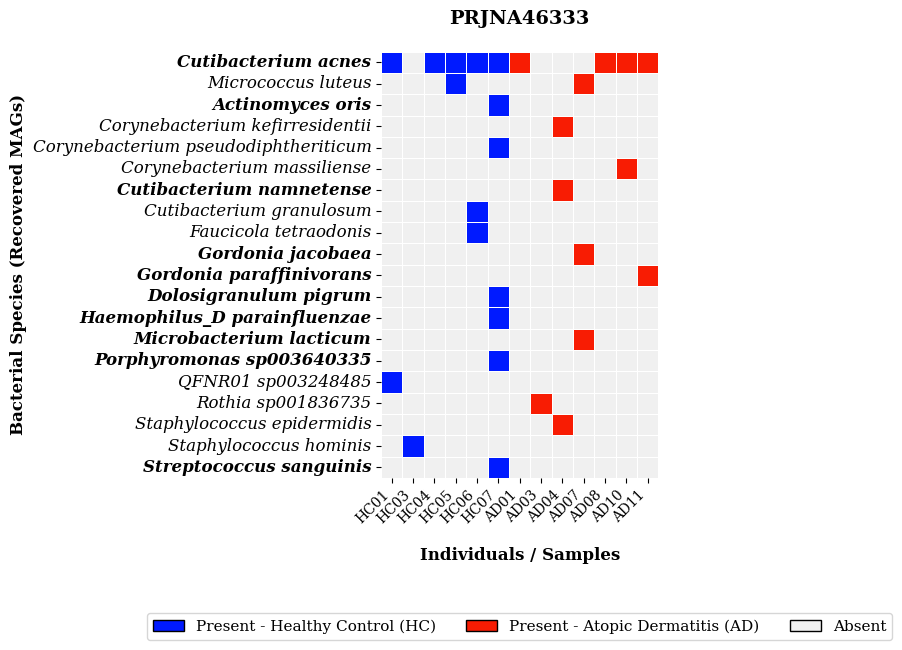


BACTERIAL SPECIES PREVALENCE TABLE (By Group)
                   Bacterial Species  HC  AD  Total
                 Cutibacterium acnes   5   4      9
                  Micrococcus luteus   1   1      2
                    Actinomyces oris   1   0      1
     Corynebacterium kefirresidentii   0   1      1
Corynebacterium pseudodiphtheriticum   1   0      1
         Corynebacterium massiliense   0   1      1
            Cutibacterium namnetense   0   1      1
            Cutibacterium granulosum   1   0      1
               Faucicola tetraodonis   1   0      1
                   Gordonia jacobaea   0   1      1
            Gordonia paraffinivorans   0   1      1
               Dolosigranulum pigrum   1   0      1
        Haemophilus_D parainfluenzae   1   0      1
             Microbacterium lacticum   0   1      1
           Porphyromonas sp003640335   1   0      1
                  QFNR01 sp003248485   1   0      1
                  Rothia sp001836735   0   1      1
          Staphyl

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib import rcParams

# Font and style setup
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
rcParams['font.size'] = 12

# File paths
DATA_PATH = "/home/marcos/PRJNA46333/PRJNA46333_2/table/master_table_mag_sialidase_gtdb_deseq2.tsv"
OUTPUT_PATH = "/home/marcos/Imagens/Resultados in silico/Individuais/Binary_Heatmap_PRJNA46333.png"

GENE_LIST = ['has_nanH', 'has_nanE', 'has_nanK', 'has_nanA', 'has_nanT']

# 1. Load data
df = pd.read_csv(DATA_PATH, sep='\t')

for gene in GENE_LIST:
    if gene in df.columns:
        df[gene] = df[gene].astype(str).str.upper().isin(['YES', 'TRUE', '1'])

perfil_counts = df.groupby(['Species'] + GENE_LIST).size().reset_index(name='count')
perfil_majoritario = perfil_counts.sort_values('count', ascending=False).drop_duplicates('Species')

df = pd.merge(df, perfil_majoritario[['Species'] + GENE_LIST], on=['Species'] + GENE_LIST)

# 2. Filter top 20 species 
top_20_species = df['Species'].value_counts().nlargest(20).index
df = df[df['Species'].isin(top_20_species)].copy()

# 3. Identify nanH positive species
if 'has_nanH' in df.columns:
    nanH_positive_species = set(
        df[df['has_nanH'] == True]['Species'].unique()
    )
else:
    nanH_positive_species = set()

# Sample ID extraction
def extract_sample_id(mag_id):
    mag_id_str = str(mag_id)
    if '_MAG_' in mag_id_str:
        return mag_id_str.split('_MAG_')[0]
    return 'Co-assembly' if 'MAGScoT' in mag_id_str else mag_id_str

df['Sample'] = df['mag_id'].apply(extract_sample_id)

# 4. Create and sort matrix
binary_matrix = pd.crosstab(df['Species'], df['Sample']).clip(upper=1)
sorted_cols = sorted(binary_matrix.columns, key=lambda x: ('HC' not in x.upper(), x))
binary_matrix = binary_matrix[sorted_cols]
binary_matrix = binary_matrix.loc[binary_matrix.sum(axis=1).sort_values(ascending=False).index]

# 5. Differentiate HC (1) and AD (2) states
for col in binary_matrix.columns:
    if 'HC' not in col.upper():
        binary_matrix[col] = binary_matrix[col].replace(1, 2)

# 6. Plotting setup
plt.figure(figsize=(max(12, len(binary_matrix.columns) * 0.9), max(7, len(binary_matrix.index) * 0.35)))
binary_cmap = mcolors.ListedColormap(['#f0f0f0', '#001aff', '#f81c03'])

ax = sns.heatmap(binary_matrix, cmap=binary_cmap, linewidths=0.5, linecolor='white', 
                 cbar=False, square=True, vmin=0, vmax=2)

# Labels and titles
plt.title("PRJNA46333", fontweight='bold', fontsize=14, pad=20)
plt.ylabel("Bacterial Species (Recovered MAGs)", fontweight='bold', fontsize=12)
plt.xlabel("Individuals / Samples", fontweight='bold', fontsize=12, labelpad=15)

# Format Y-axis labels (dynamic bold)
for label in ax.get_yticklabels():
    species_name = label.get_text()
    if species_name in nanH_positive_species:
        label.set_fontweight('bold')
    else:
        label.set_fontweight('normal')
    label.set_fontstyle('italic')

plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right', fontsize=10)

# Legend setup
legend_elements = [
    Patch(facecolor="#001aff", edgecolor='black', label='Present - Healthy Control (HC)'),
    Patch(facecolor="#f81c03", edgecolor='black', label='Present - Atopic Dermatitis (AD)'),
    Patch(facecolor='#f0f0f0', edgecolor='black', label='Absent')
]
ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=3, frameon=True, fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
plt.show()
hc_counts = (binary_matrix == 1).sum(axis=1)
ad_counts = (binary_matrix == 2).sum(axis=1)
total_counts = (binary_matrix > 0).sum(axis=1)

prevalence_df = pd.DataFrame({
    'Bacterial Species': binary_matrix.index,
    'HC': hc_counts.values,
    'AD': ad_counts.values,
    'Total': total_counts.values
})

print("\n" + "="*80)
print("BACTERIAL SPECIES PREVALENCE TABLE (By Group)")
print("="*80)
print(prevalence_df.to_string(index=False))
print("="*80 + "\n")

Integration of three studys

Differencial Expression of Individual MAGs and Sialic Acid Metabolism Across Three Studies

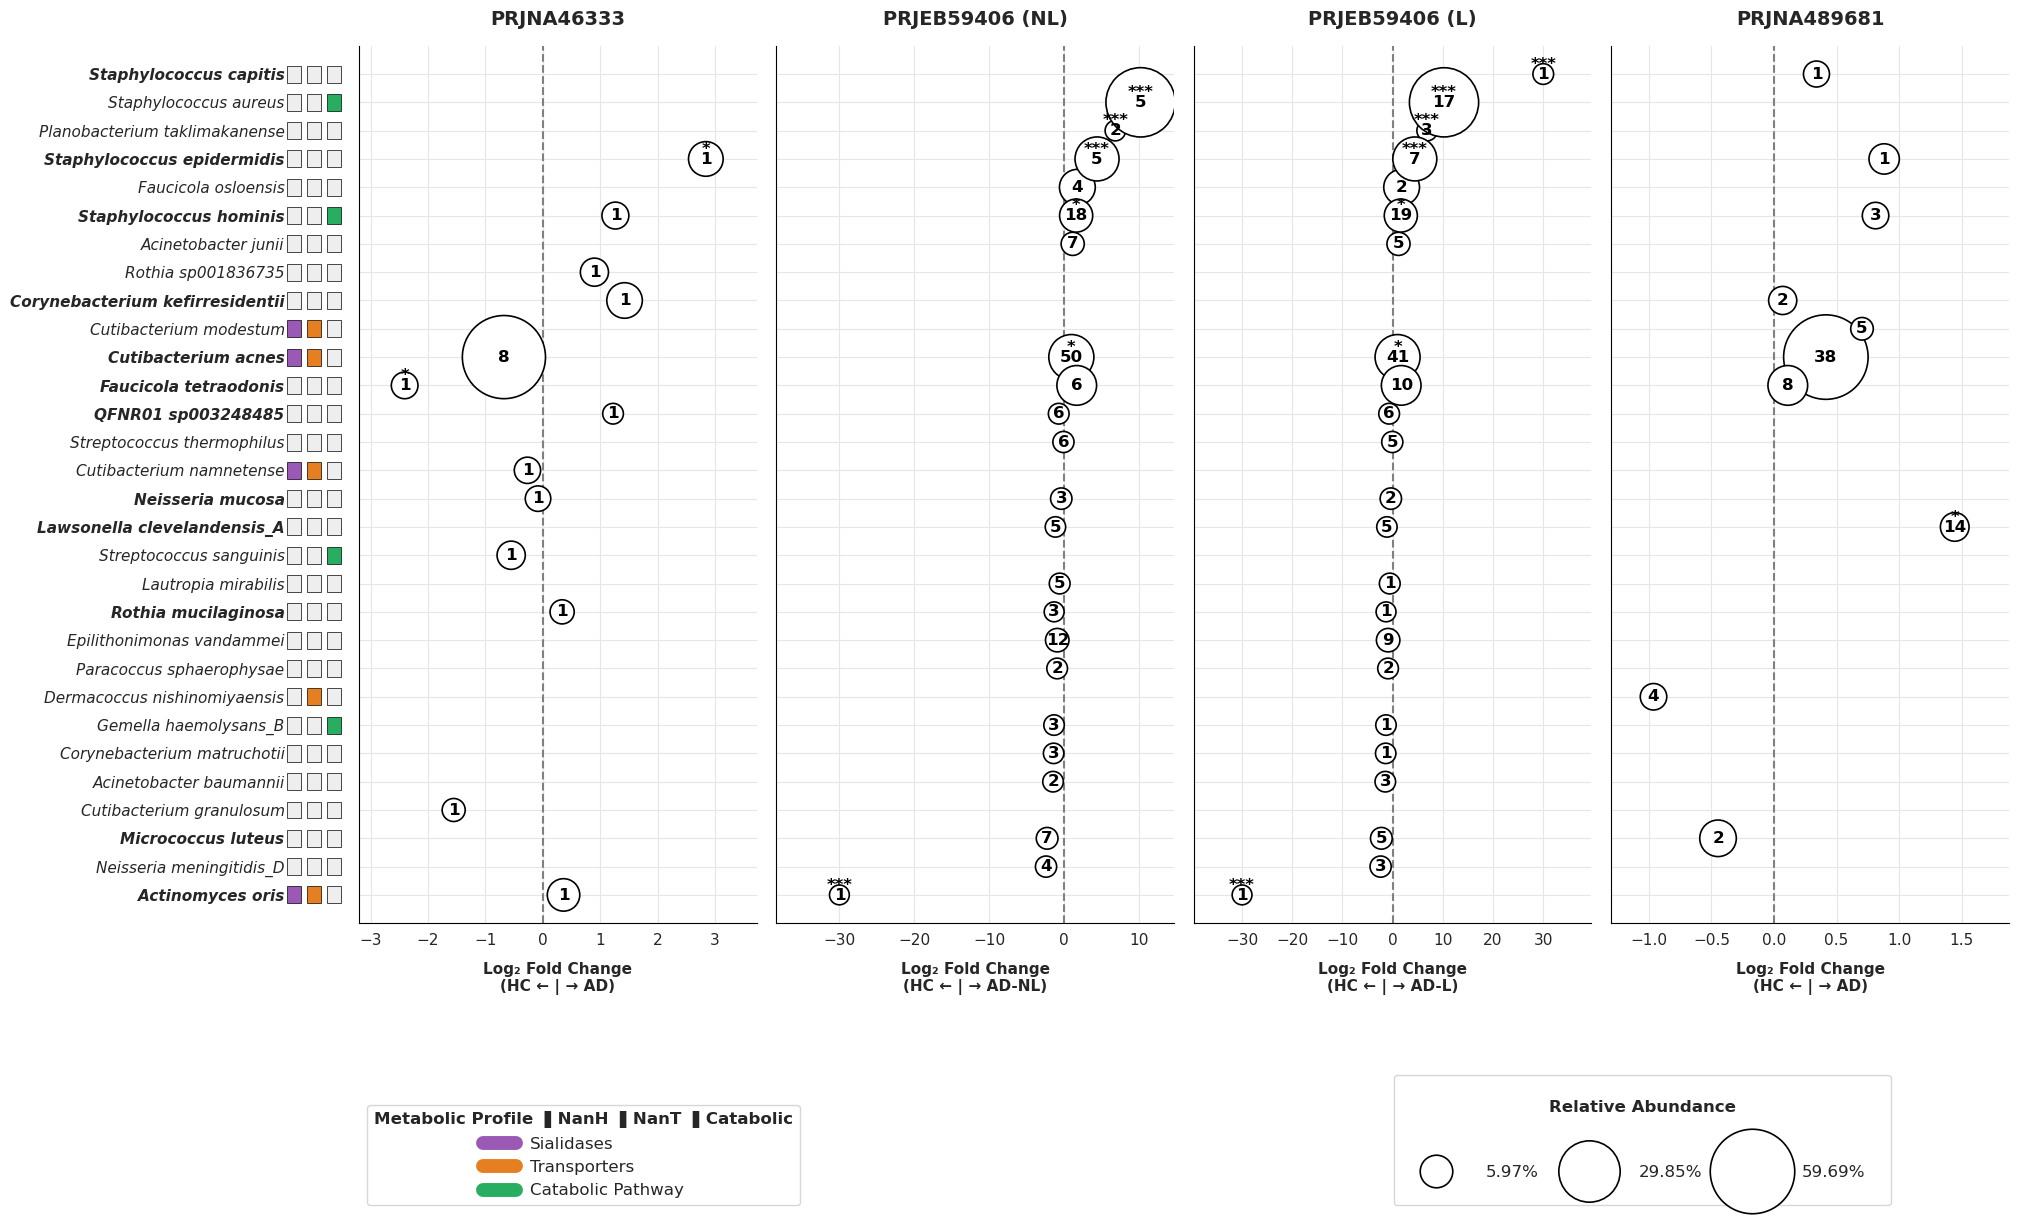

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import os
from matplotlib.lines import Line2D
from matplotlib import rcParams

# ── 1. STYLE CONFIGURATION ──────────────────────────────────────────────────
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
rcParams['font.size'] = 12

sns.set_style("whitegrid", {'axes.edgecolor': 'black', 'grid.color': '.90', 'grid.linestyle': '-'})

# ── 2. PATHWAYS AND SETTINGS ────────────────────────────────────────────────
STUDIES = {
    'PRJNA46333': "/home/marcos/PRJNA46333/PRJNA46333_2/table/master_table_mag_sialidase_gtdb_deseq2.tsv",
    'PRJEB59406': "/home/marcos/PRJEB59406/table/master_table_mag_sialidase_gtdb_deseq2.tsv",
    'PRJNA489681': "/home/marcos/PRJNA489681/table/master_table_mag_sialidase_gtdb_deseq2.tsv"
}

OUTPUT_PATH = "/home/marcos/Imagens/Resultados in silico/Geral/Final_DESeq2_Metabolic_Plot_Panels_catabolism.svg"

METABOLIC_PALETTE = {
    'Sialidases': '#9b59b6',
    'Transporters': '#e67e22',
    'Catabolic Pathway': '#27ae60',
    'Inactive': '#eeeeee'
}
GENE_LIST = ['has_nanH', 'has_nanE', 'has_nanK', 'has_nanA', 'has_nanT']

# ── 3. DATA INTEGRATION ─────────────────────────────────────────────────────
df_list = []
plot_studies = []

for study_id, path in STUDIES.items():
    if os.path.exists(path):
        temp_df = pd.read_csv(path, sep='\t')
        
        # Rule for splitting PRJEB59406 into two sub-studies based on mag_id patterns
        if study_id == 'PRJEB59406':
            mask_nl = temp_df['mag_id'].str.contains('NL__', na=False) | temp_df['mag_id'].str.contains('HC_', na=False)
            df_nl = temp_df[mask_nl].copy()
            study_nl_name = 'PRJEB59406 (NL)'
            df_nl['Study'] = study_nl_name
            df_list.append(df_nl)
            plot_studies.append(study_nl_name)
            
            mask_l = (temp_df['mag_id'].str.contains('L__', na=False) & ~temp_df['mag_id'].str.contains('NL__', na=False)) | temp_df['mag_id'].str.contains('HC_', na=False)
            df_l = temp_df[mask_l].copy()
            study_l_name = 'PRJEB59406 (L)'
            df_l['Study'] = study_l_name
            df_list.append(df_l)
            plot_studies.append(study_l_name)
            
        else:
            temp_df['Study'] = study_id
            df_list.append(temp_df)
            plot_studies.append(study_id)
    else:
        print(f"File not found: {path}")

if not df_list:
    raise FileNotFoundError("Nenhum arquivo DESeq2 foi encontrado.")

df = pd.concat(df_list, ignore_index=True)

for col in ['baseMean', 'log2FoldChange', 'padj']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['padj'] = df['padj'].fillna(1.0)
df['log2FoldChange'] = df['log2FoldChange'].fillna(0.0)
df['baseMean'] = df['baseMean'].fillna(0.0)

for gene in GENE_LIST:
    if gene in df.columns:
        df[gene] = df[gene].astype(str).str.upper().isin(['YES', 'TRUE', '1'])

# ── 4. AGGREGATION AND FILTERING ────────────────────────────────────────────
perfil_counts = df.groupby(['Species'] + GENE_LIST).size().reset_index(name='count')
perfil_majoritario = perfil_counts.sort_values('count', ascending=False).drop_duplicates('Species')

df_filtrado = pd.merge(df, perfil_majoritario[['Species'] + GENE_LIST], on=['Species'] + GENE_LIST)

bin_counts = df_filtrado.groupby(['Study', 'Species']).size().reset_index(name='bin_count')

# --- AQUI ESTÁ A ALTERAÇÃO PRINCIPAL ---
df_agg = df_filtrado.groupby(['Study', 'Species']).agg({
    'baseMean': 'first', # Antes era 'sum'. Agora retém o valor de 1 única ocorrência/MAG da espécie.
    'log2FoldChange': 'mean',
    'padj': 'min',
    **{g: 'any' for g in GENE_LIST if g in df_filtrado.columns}
}).reset_index()

df_agg = pd.merge(df_agg, bin_counts, on=['Study', 'Species'])

# Sum baseMean across studies for each species (Abundância Relativa intrapainel)
all_study = df_agg.groupby('Study')['baseMean'].transform('sum')
df_agg['Relative_Abundance'] = (df_agg['baseMean'] / all_study) * 100

# Extract the base study name (without any suffixes) for counting unique studies
df_agg['Base_Study'] = df_agg['Study'].apply(lambda x: x.split(' ')[0])

# Count the number of unique base studies for each species
study_counts = df_agg.groupby('Species')['Base_Study'].nunique()
multi_study_species = set(study_counts[study_counts >= 2].index)

# As Top 30 usam as abundâncias basais agora não-infladas (somadas apenas entre os 3 estudos/condições)
top_30_species = df_agg.groupby('Species')['baseMean'].sum().nlargest(30).index.tolist()
df_plot = df_agg[df_agg['Species'].isin(top_30_species)].copy()

species_order = df_plot.groupby('Species')['log2FoldChange'].mean().sort_values().index.tolist()
sp_to_y = {sp: i for i, sp in enumerate(species_order)}
df_plot['Y_idx'] = df_plot['Species'].map(sp_to_y)

# ── 5. RELATIVE ABUNDANCE ───────────────────────────────────────────────────
study_totals = df_plot.groupby('Study')['baseMean'].transform('sum')
df_plot['Relative_Abundance'] = (df_plot['baseMean'] / study_totals) * 100

# ── 6. FIGURE CONFIGURATION ─────────────────────────────────────────────────
num_sp = len(species_order)
num_panels = len(plot_studies)

fig, axes = plt.subplots(1, num_panels, figsize=(5.5 * num_panels, max(10, num_sp * 0.45)),
                         sharey=True, gridspec_kw={'wspace': 0.05})

if num_panels == 1:
    axes = [axes]

meta_df = df_plot.groupby('Species').agg({g: 'any' for g in GENE_LIST}).reset_index()

# ── 7. PLOTTING LOOP ────────────────────────────────────────────────────────
for ax, study in zip(axes, plot_studies):
    sub_df = df_plot[df_plot['Study'] == study]
    
    sizes = (sub_df['Relative_Abundance'] / df_plot['Relative_Abundance'].max() * 3500) + 200
    
    ax.scatter(x=sub_df['log2FoldChange'], y=sub_df['Y_idx'], s=sizes, color='white',
               edgecolors='black', linewidths=1.2, alpha=1.0, zorder=3)
    
    for _, row in sub_df.iterrows():
        ax.text(row['log2FoldChange'], row['Y_idx'], str(int(row['bin_count'])),
                ha='center', va='center', fontsize=12, fontweight='bold', color='black', zorder=4)
        
        sig = "***" if row['padj'] < 0.001 else "**" if row['padj'] < 0.01 else "*" if row['padj'] < 0.05 else ""
        if sig:
            ax.text(row['log2FoldChange'], row['Y_idx'] + 0.35, sig, ha='center', va='center',
                    fontsize=12, fontweight='bold', color='black', zorder=4)
            
    ax.axvline(x=0, color='gray', linestyle='--', lw=1.5, zorder=1)
    ax.set_title(f"{study}", fontweight='bold', fontsize=14, pad=15)
    
    if "(NL)" in study:
        ax.set_xlabel("Log₂ Fold Change\n(HC ← | → AD-NL)", fontsize=11, fontweight='bold', labelpad=10)
    elif "(L)" in study:
        ax.set_xlabel("Log₂ Fold Change\n(HC ← | → AD-L)", fontsize=11, fontweight='bold', labelpad=10)
    else:
        ax.set_xlabel("Log₂ Fold Change\n(HC ← | → AD)", fontsize=11, fontweight='bold', labelpad=10)
    
    ax.tick_params(axis='x', labelsize=11)
    
    xmin, xmax = ax.get_xlim()
    ax.set_xlim(xmin * 1.20, xmax * 1.20)
    ax.set_ylim(-1, num_sp)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── 8. Y-AXIS LABELS AND METABOLIC BARS ─────────────────────────────────────
axes[0].set_yticks(range(num_sp))
axes[0].set_yticklabels(species_order, fontstyle='italic', fontsize=11)
axes[0].tick_params(axis='y', pad=50)

for label in axes[0].get_yticklabels():
    if label.get_text() in multi_study_species:
        label.set_fontweight('bold')

for i, sp in enumerate(species_order):
    if sp in meta_df['Species'].values:
        row = meta_df[meta_df['Species'] == sp].iloc[0]
        metabolic_info = [('has_nanH', 'Sialidases'), ('has_nanT', 'Transporters'), ('cat', 'Catabolic Pathway')]

        for j, (g_key, p_key) in enumerate(metabolic_info):
            if g_key == 'cat':
                present = all(row.get(g, False) for g in ['has_nanA', 'has_nanE', 'has_nanK'])
            else:
                present = row.get(g_key, False)

            color = METABOLIC_PALETTE[p_key] if present else METABOLIC_PALETTE['Inactive']
            axes[0].add_patch(plt.Rectangle((-0.18 + (j * 0.05), i - 0.30), 0.035, 0.60, clip_on=False,
                                            transform=axes[0].get_yaxis_transform(), facecolor=color, edgecolor='black', lw=0.5))

# ── 9. GLOBAL LEGEND ────────────────────────────────────────────────────────
size_samples = [df_plot['Relative_Abundance'].max() * 0.1, df_plot['Relative_Abundance'].max() * 0.5, df_plot['Relative_Abundance'].max()]
size_legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'{val:.2f}%',
           markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.2, alpha=1.0,
           markersize=np.sqrt(((val / df_plot['Relative_Abundance'].max()) * 3500) + 200))
    for val in size_samples if val > 0
]
if size_legend_elements:
    fig.legend(handles=size_legend_elements, title="Relative Abundance",
               loc='lower right', bbox_to_anchor=(0.90, 0.0351), ncol=3, frameon=True,
               title_fontproperties={'weight': 'bold'},
               labelspacing=3.0, borderpad=1.5, handletextpad=2.0)    
   
legend_els = [Line2D([0], [0], color=c, lw=10, label=l) for l, c in METABOLIC_PALETTE.items() if l != 'Inactive']
fig.legend(handles=legend_els, title="Metabolic Profile  ▌NanH  ▌NanT  ▌Catabolic",
           loc='lower left', bbox_to_anchor=(0.2, 0.0351), ncol=1, frameon=True,
           title_fontproperties={'weight': 'bold'})

# ── 10. LAYOUT & SAVE ───────────────────────────────────────────────────────
plt.subplots_adjust(left=0.20, right=0.95, top=0.90, bottom=0.25)
plt.savefig(OUTPUT_PATH, format='svg', bbox_inches='tight')
plt.show()

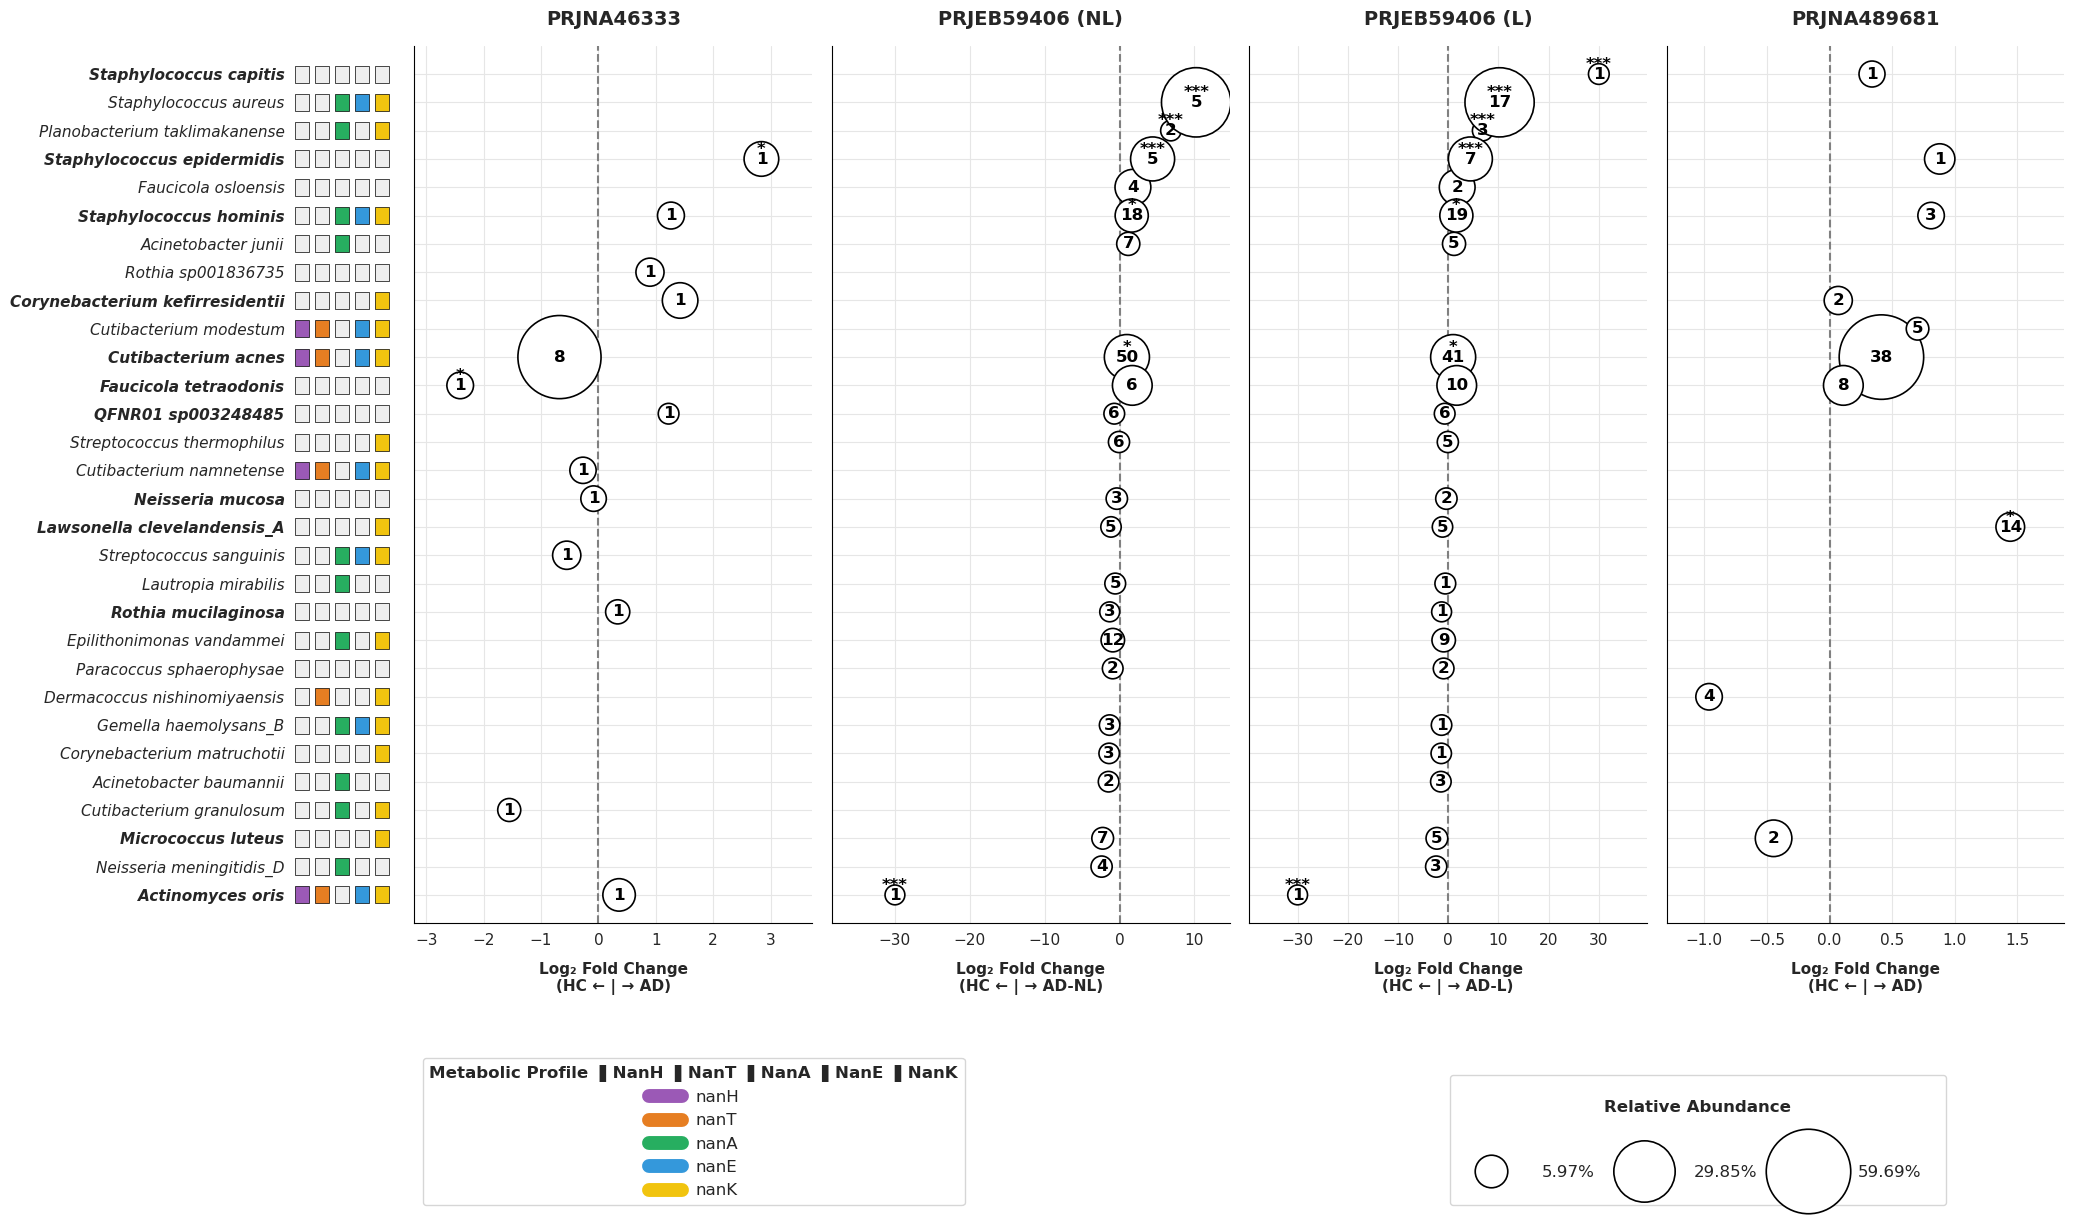

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import os
from matplotlib.lines import Line2D
from matplotlib import rcParams

# ── 1. STYLE CONFIGURATION ──────────────────────────────────────────────────
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
rcParams['font.size'] = 12

sns.set_style("whitegrid", {'axes.edgecolor': 'black', 'grid.color': '.90', 'grid.linestyle': '-'})

# ── 2. PATHWAYS AND SETTINGS ────────────────────────────────────────────────
STUDIES = {
    'PRJNA46333': "/home/marcos/PRJNA46333/PRJNA46333_2/table/master_table_mag_sialidase_gtdb_deseq2.tsv",
    'PRJEB59406': "/home/marcos/PRJEB59406/table/master_table_mag_sialidase_gtdb_deseq2.tsv",
    'PRJNA489681': "/home/marcos/PRJNA489681/table/master_table_mag_sialidase_gtdb_deseq2.tsv"
}

OUTPUT_PATH = "/home/marcos/Imagens/Resultados in silico/Geral/Final_DESeq2_Metabolic_Plot_Panels.png"

METABOLIC_PALETTE = {
    'nanH': '#9b59b6',
    'nanT': '#e67e22',
    'nanA': '#27ae60',
    'nanE': '#3498db',
    'nanK': '#f1c40f',
    'Inactive': '#eeeeee'
}
GENE_LIST = ['has_nanH', 'has_nanE', 'has_nanK', 'has_nanA', 'has_nanT']

# ── 3. DATA INTEGRATION ─────────────────────────────────────────────────────
df_list = []
plot_studies = []

for study_id, path in STUDIES.items():
    if os.path.exists(path):
        temp_df = pd.read_csv(path, sep='\t')
        
        # Rule for splitting PRJEB59406 into two sub-studies based on mag_id patterns
        if study_id == 'PRJEB59406':
            mask_nl = temp_df['mag_id'].str.contains('NL__', na=False) | temp_df['mag_id'].str.contains('HC_', na=False)
            df_nl = temp_df[mask_nl].copy()
            study_nl_name = 'PRJEB59406 (NL)'
            df_nl['Study'] = study_nl_name
            df_list.append(df_nl)
            plot_studies.append(study_nl_name)
            
            mask_l = (temp_df['mag_id'].str.contains('L__', na=False) & ~temp_df['mag_id'].str.contains('NL__', na=False)) | temp_df['mag_id'].str.contains('HC_', na=False)
            df_l = temp_df[mask_l].copy()
            study_l_name = 'PRJEB59406 (L)'
            df_l['Study'] = study_l_name
            df_list.append(df_l)
            plot_studies.append(study_l_name)
            
        else:
            temp_df['Study'] = study_id
            df_list.append(temp_df)
            plot_studies.append(study_id)
    else:
        print(f"File not found: {path}")

if not df_list:
    raise FileNotFoundError("Nenhum arquivo DESeq2 foi encontrado.")

df = pd.concat(df_list, ignore_index=True)

for col in ['baseMean', 'log2FoldChange', 'padj']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['padj'] = df['padj'].fillna(1.0)
df['log2FoldChange'] = df['log2FoldChange'].fillna(0.0)
df['baseMean'] = df['baseMean'].fillna(0.0)

for gene in GENE_LIST:
    if gene in df.columns:
        df[gene] = df[gene].astype(str).str.upper().isin(['YES', 'TRUE', '1'])

# ── 4. AGGREGATION AND FILTERING ────────────────────────────────────────────
perfil_counts = df.groupby(['Species'] + GENE_LIST).size().reset_index(name='count')
perfil_majoritario = perfil_counts.sort_values('count', ascending=False).drop_duplicates('Species')

df_filtrado = pd.merge(df, perfil_majoritario[['Species'] + GENE_LIST], on=['Species'] + GENE_LIST)

bin_counts = df_filtrado.groupby(['Study', 'Species']).size().reset_index(name='bin_count')

# --- AQUI ESTÁ A ALTERAÇÃO PRINCIPAL ---
df_agg = df_filtrado.groupby(['Study', 'Species']).agg({
    'baseMean': 'first', # Antes era 'sum'. Agora retém o valor de 1 única ocorrência/MAG da espécie.
    'log2FoldChange': 'mean',
    'padj': 'min',
    **{g: 'any' for g in GENE_LIST if g in df_filtrado.columns}
}).reset_index()

df_agg = pd.merge(df_agg, bin_counts, on=['Study', 'Species'])

# Sum baseMean across studies for each species (Abundância Relativa intrapainel)
all_study = df_agg.groupby('Study')['baseMean'].transform('sum')
df_agg['Relative_Abundance'] = (df_agg['baseMean'] / all_study) * 100

# Extract the base study name (without any suffixes) for counting unique studies
df_agg['Base_Study'] = df_agg['Study'].apply(lambda x: x.split(' ')[0])

# Count the number of unique base studies for each species
study_counts = df_agg.groupby('Species')['Base_Study'].nunique()
multi_study_species = set(study_counts[study_counts >= 2].index)

# As Top 30 usam as abundâncias basais agora não-infladas (somadas apenas entre os 3 estudos/condições)
top_30_species = df_agg.groupby('Species')['baseMean'].sum().nlargest(30).index.tolist()
df_plot = df_agg[df_agg['Species'].isin(top_30_species)].copy()

species_order = df_plot.groupby('Species')['log2FoldChange'].mean().sort_values().index.tolist()
sp_to_y = {sp: i for i, sp in enumerate(species_order)}
df_plot['Y_idx'] = df_plot['Species'].map(sp_to_y)

# ── 5. RELATIVE ABUNDANCE ───────────────────────────────────────────────────
study_totals = df_plot.groupby('Study')['baseMean'].transform('sum')
df_plot['Relative_Abundance'] = (df_plot['baseMean'] / study_totals) * 100

# ── 6. FIGURE CONFIGURATION ─────────────────────────────────────────────────
num_sp = len(species_order)
num_panels = len(plot_studies)

fig, axes = plt.subplots(1, num_panels, figsize=(5.5 * num_panels, max(10, num_sp * 0.45)),
                         sharey=True, gridspec_kw={'wspace': 0.05})

if num_panels == 1:
    axes = [axes]

meta_df = df_plot.groupby('Species').agg({g: 'any' for g in GENE_LIST}).reset_index()

# ── 7. PLOTTING LOOP ────────────────────────────────────────────────────────
for ax, study in zip(axes, plot_studies):
    sub_df = df_plot[df_plot['Study'] == study]
    
    sizes = (sub_df['Relative_Abundance'] / df_plot['Relative_Abundance'].max() * 3500) + 200
    
    ax.scatter(x=sub_df['log2FoldChange'], y=sub_df['Y_idx'], s=sizes, color='white',
               edgecolors='black', linewidths=1.2, alpha=1.0, zorder=3)
    
    for _, row in sub_df.iterrows():
        ax.text(row['log2FoldChange'], row['Y_idx'], str(int(row['bin_count'])),
                ha='center', va='center', fontsize=12, fontweight='bold', color='black', zorder=4)
        
        sig = "***" if row['padj'] < 0.001 else "**" if row['padj'] < 0.01 else "*" if row['padj'] < 0.05 else ""
        if sig:
            ax.text(row['log2FoldChange'], row['Y_idx'] + 0.35, sig, ha='center', va='center',
                    fontsize=12, fontweight='bold', color='black', zorder=4)
            
    ax.axvline(x=0, color='gray', linestyle='--', lw=1.5, zorder=1)
    ax.set_title(f"{study}", fontweight='bold', fontsize=14, pad=15)
    
    if "(NL)" in study:
        ax.set_xlabel("Log₂ Fold Change\n(HC ← | → AD-NL)", fontsize=11, fontweight='bold', labelpad=10)
    elif "(L)" in study:
        ax.set_xlabel("Log₂ Fold Change\n(HC ← | → AD-L)", fontsize=11, fontweight='bold', labelpad=10)
    else:
        ax.set_xlabel("Log₂ Fold Change\n(HC ← | → AD)", fontsize=11, fontweight='bold', labelpad=10)
    
    ax.tick_params(axis='x', labelsize=11)
    
    xmin, xmax = ax.get_xlim()
    ax.set_xlim(xmin * 1.20, xmax * 1.20)
    ax.set_ylim(-1, num_sp)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── 8. Y-AXIS LABELS AND METABOLIC BARS ─────────────────────────────────────
axes[0].set_yticks(range(num_sp))
axes[0].set_yticklabels(species_order, fontstyle='italic', fontsize=11)
axes[0].tick_params(axis='y', pad=90)

for label in axes[0].get_yticklabels():
    if label.get_text() in multi_study_species:
        label.set_fontweight('bold')

for i, sp in enumerate(species_order):
    if sp in meta_df['Species'].values:
        row = meta_df[meta_df['Species'] == sp].iloc[0]
        metabolic_info = [('has_nanH', 'nanH'), ('has_nanT', 'nanT'), ('has_nanA', 'nanA'), ('has_nanE', 'nanE'), ('has_nanK', 'nanK')]

        for j, (g_key, p_key) in enumerate(metabolic_info):
            if g_key == 'cat':
                present = all(row.get(g, False) for g in ['has_nanA', 'has_nanE', 'has_nanK'])
            else:
                present = row.get(g_key, False)

            color = METABOLIC_PALETTE[p_key] if present else METABOLIC_PALETTE['Inactive']
            axes[0].add_patch(plt.Rectangle((-0.30 + (j * 0.05), i - 0.30), 0.035, 0.60, clip_on=False,
                                            transform=axes[0].get_yaxis_transform(), facecolor=color, edgecolor='black', lw=0.5))

# ── 9. GLOBAL LEGEND ────────────────────────────────────────────────────────
size_samples = [df_plot['Relative_Abundance'].max() * 0.1, df_plot['Relative_Abundance'].max() * 0.5, df_plot['Relative_Abundance'].max()]
size_legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'{val:.2f}%',
           markerfacecolor='white', markeredgecolor='black', markeredgewidth=1.2, alpha=1.0,
           markersize=np.sqrt(((val / df_plot['Relative_Abundance'].max()) * 3500) + 200))
    for val in size_samples if val > 0
]
if size_legend_elements:
    fig.legend(handles=size_legend_elements, title="Relative Abundance",
               loc='lower right', bbox_to_anchor=(0.90, 0.0351), ncol=3, frameon=True,
               title_fontproperties={'weight': 'bold'},
               labelspacing=3.0, borderpad=1.5, handletextpad=2.0)    
   
legend_els = [Line2D([0], [0], color=c, lw=10, label=l) for l, c in METABOLIC_PALETTE.items() if l != 'Inactive']
fig.legend(handles=legend_els, title="Metabolic Profile  ▌NanH  ▌NanT  ▌NanA  ▌NanE  ▌NanK",
           loc='lower left', bbox_to_anchor=(0.2, 0.0351), ncol=1, frameon=True,
           title_fontproperties={'weight': 'bold'})

# ── 10. LAYOUT & SAVE ───────────────────────────────────────────────────────
plt.subplots_adjust(left=0.20, right=0.95, top=0.90, bottom=0.25)
plt.savefig(OUTPUT_PATH, format='svg', bbox_inches='tight')
plt.show()